# 第四问：七日滚动储能敏感性分析

本 notebook 在 Q2 的负载/光伏预测和日内储能 LP 基础上，构造七日滚动模拟。每个窗口连续优化未来 7 天，只有第 7 天施加终端储能目标；因此这里的 `terminal_target_kwh=6000` 表示七日末目标，而不是每天收盘都回到 6000。

## 重点分析
- 终端储能目标：`4000, 5000, 6000, 7000, 8000 kWh`。
- 终端软惩罚系数：`0, 0.15, 0.30, 0.45, 0.60, 0.90 元/kWh`。
- 风险分位数 q：`0.70` 到 `0.95`。
- 初始储能：`4000` 到 `8000 kWh`。
- 充放电效率：`0.80, 0.85, 0.90, 0.95`，作为设备参数的鲁棒性检查。

所有成本均按真实电价结算；紧急购电按 Q2 的 5 倍电价计费。分析结果写入 `q4/sensitivity_outputs/`。

In [83]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while ROOT.name != 'CUMCM_2026' and ROOT.parent != ROOT:
    ROOT = ROOT.parent
SUBMIT = ROOT / 'submit'
if str(SUBMIT) not in sys.path:
    sys.path.insert(0, str(SUBMIT))
import q2

OUT = ROOT / 'q4' / 'sensitivity_outputs'
OUT.mkdir(parents=True, exist_ok=True)
print('项目根目录:', ROOT)
print('输出目录:', OUT)

项目根目录: E:\桌面\CUMCM_2026
输出目录: E:\桌面\CUMCM_2026\q4\sensitivity_outputs


## 参数判断

**一定要分析**的是七日末终端储能目标：它直接决定模型是否在最后一天预留电量，通常会影响整个七日的充放电时序、紧急购电量和总成本。

**非常适合分析**的参数包括：风险分位数 q（风险偏好）、终端软惩罚系数（目标的硬度）、初始储能（跨窗口状态假设）和充放电效率（电池损耗）。储能上下限、最大充放电功率、紧急购电倍数也有价值，但它们更适合在本 notebook 的框架上增加更大规模的设备参数网格；本次先保留为模型口径固定值，避免一次实验维度过多。

解释结果时应同时观察：总成本、计划购电成本、紧急购电量、七日末实际储能和终端偏差。只看总成本可能把“少留库存”误判成“策略更好”。

In [84]:
actual_path, price_path, _ = q2.default_paths()
dates, load, pv, prices = q2.load_inputs(actual_path, price_path)
pred_load, pred_pv, scenarios = q2.forecast_scenarios(dates, load, pv)
run_days = np.where((dates >= pd.Timestamp('2025-02-01')) & (dates <= pd.Timestamp('2025-12-25')))[0]
# 取分布均匀的 12 个起点，既覆盖季节变化又控制重复求解时间。
window_starts = np.unique(np.linspace(run_days.min(), run_days.max(), 12).round().astype(int))
window_starts = [int(d) for d in window_starts if d + 6 < len(dates) and d in scenarios]
print(f'数据: {len(dates)} 天；七日窗口数: {len(window_starts)}')
print('窗口起点:', [dates[d].strftime('%Y-%m-%d') for d in window_starts])

数据: 365 天；七日窗口数: 12
窗口起点: ['2025-02-01', '2025-03-03', '2025-04-01', '2025-05-01', '2025-05-31', '2025-06-30', '2025-07-29', '2025-08-28', '2025-09-27', '2025-10-27', '2025-11-25', '2025-12-25']


In [85]:
def simulate_window(start, q=0.85, terminal_target=6000.0, penalty=0.45, initial_storage=None):
    '''模拟一个七日窗口，仅第七天使用终端软惩罚。'''
    storage = q2.CFG['initial_storage_kwh'] if initial_storage is None else float(initial_storage)
    rows = []
    for offset in range(7):
        day = start + offset
        if day not in scenarios:
            raise ValueError(f'日期 {dates[day].date()} 缺少预测情景')
        net_forecast = np.quantile(scenarios[day], q, axis=0)
        is_terminal_day = offset == 6
        plan = q2.solve_dispatch(
            net_forecast * q2.CFG['interval_hours'], prices,
            initial_storage_kwh=storage,
            terminal_target_kwh=terminal_target if is_terminal_day else None,
            terminal_penalty_yuan_per_kwh=penalty if is_terminal_day else 0.0,
        )
        actual_net = (load[day] - pv[day]) * q2.CFG['interval_hours']
        emergency, unused = q2.execute_fixed_plan(plan, actual_net)
        planned_cost = float(prices @ plan['grid'])
        emergency_cost = float(q2.CFG['emergency_multiplier'] * prices @ emergency)
        storage = float(plan['storage'][-1])
        rows.append({
            'window_start': dates[start].date(), 'date': dates[day].date(),
            'day_in_window': offset + 1, 'q': q,
            'planned_cost_yuan': planned_cost, 'emergency_cost_yuan': emergency_cost,
            'total_cost_yuan': planned_cost + emergency_cost,
            'emergency_kwh': float(emergency.sum()), 'unused_kwh': float(unused.sum()),
            'storage_end_kwh': storage, 'terminal_target_kwh': terminal_target,
            'terminal_day': is_terminal_day, 'solver': plan['solver'],
        })
    detail = pd.DataFrame(rows)
    terminal = detail.iloc[-1]
    summary = {
        'window_start': str(dates[start].date()), 'q': q,
        'terminal_target_kwh': terminal_target, 'penalty_yuan_per_kwh': penalty,
        'initial_storage_kwh': q2.CFG['initial_storage_kwh'] if initial_storage is None else initial_storage,
        'total_cost_yuan': detail['total_cost_yuan'].sum(),
        'planned_cost_yuan': detail['planned_cost_yuan'].sum(),
        'emergency_cost_yuan': detail['emergency_cost_yuan'].sum(),
        'emergency_kwh': detail['emergency_kwh'].sum(),
        'terminal_storage_kwh': terminal['storage_end_kwh'],
        'terminal_deviation_kwh': terminal['storage_end_kwh'] - terminal_target,
    }
    return summary, detail

def run_grid(values, parameter, **fixed):
    records = []
    for value in values:
        for start in window_starts:
            kwargs = dict(fixed)
            kwargs[parameter] = value
            summary, _ = simulate_window(start, **kwargs)
            records.append(summary)
    return pd.DataFrame(records)

## 1. 指定分析：七日末终端储能目标

In [86]:
terminal_values = [4000, 5000, 6000, 7000, 8000]
# 0.45 元/kWh 在该数据尺度下可能无法改变末日调度；主分析采用 5.0，
# 并在下一节扫描惩罚系数，检查结果对该口径的稳健性。
terminal_results = run_grid(terminal_values, 'terminal_target', q=0.85, penalty=5.0)
terminal_summary = terminal_results.groupby('terminal_target_kwh', as_index=False).agg(
    total_cost_yuan=('total_cost_yuan', 'mean'),
    emergency_kwh=('emergency_kwh', 'mean'),
    terminal_storage_kwh=('terminal_storage_kwh', 'mean'),
    terminal_deviation_kwh=('terminal_deviation_kwh', 'mean'),
)
terminal_summary.to_csv(OUT / '01_terminal_target_summary.csv', index=False, encoding='utf-8-sig')
display(terminal_summary.style.format('{:,.2f}'))

,terminal_target_kwh,total_cost_yuan,emergency_kwh,terminal_storage_kwh,terminal_deviation_kwh
0,"4,000.00","316,072.61","7,126.84","4,000.00",0.00
1,"5,000.00","316,541.35","7,126.84","5,000.00",0.00
2,"6,000.00","317,012.23","7,126.84","6,000.00",0.00
3,"7,000.00","317,483.34","7,126.84","7,000.00",0.00
4,"8,000.00","317,954.58","7,126.84","8,000.00",0.00


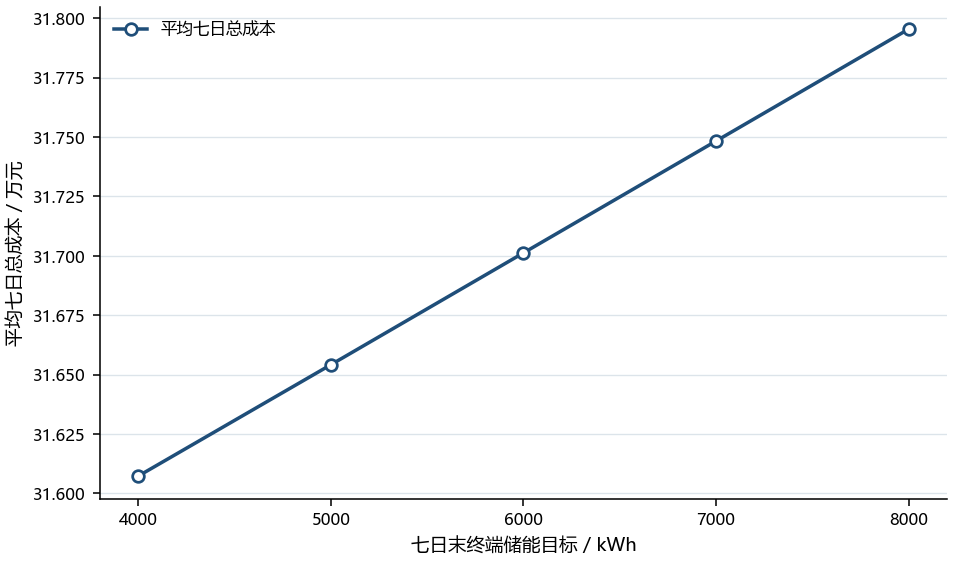

In [87]:
# 正文级主图：单一指标、统一比例和论文配色，避免多个量纲挤在同一坐标轴。
from matplotlib import font_manager

PAPER_FIG_DIR = ROOT / 'paper' / 'figures' / 'q4'
PAPER_FIG_DIR.mkdir(parents=True, exist_ok=True)
font_candidates = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Arial Unicode MS', 'DejaVu Sans']
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
chosen_font = next((f for f in font_candidates if f in available_fonts), 'DejaVu Sans')
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': [chosen_font, 'DejaVu Sans'],
    'axes.unicode_minus': False, 'font.size': 9.5,
    'axes.labelsize': 9.5, 'xtick.labelsize': 8.5, 'ytick.labelsize': 8.5,
    'legend.fontsize': 8.5, 'axes.titlesize': 10.5,
    'axes.linewidth': 0.8, 'lines.linewidth': 1.8,
    'figure.dpi': 140, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

def save_publication_figure(fig, stem):
    '''同时输出 PNG、PDF 和 SVG，便于论文插图和后期排版。'''
    for folder in (OUT, PAPER_FIG_DIR):
        fig.savefig(folder / f'{stem}.png', dpi=300, bbox_inches='tight', pad_inches=0.05)
        fig.savefig(folder / f'{stem}.pdf', bbox_inches='tight', pad_inches=0.05)
        fig.savefig(folder / f'{stem}.svg', bbox_inches='tight', pad_inches=0.05)

fig, ax = plt.subplots(figsize=(6.8, 4.0), constrained_layout=True)
x = terminal_summary['terminal_target_kwh']
y = terminal_summary['total_cost_yuan'] / 1e4
ax.plot(x, y, 'o-', color='#1F4E79', markerfacecolor='white', markeredgewidth=1.4, label='平均七日总成本')
ax.set_xlabel('七日末终端储能目标 / kWh')
ax.set_ylabel('平均七日总成本 / 万元')
ax.set_xticks(x)
ax.grid(axis='y', color='#D9E1E8', linewidth=0.7, alpha=0.9)
ax.grid(axis='x', visible=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='best', frameon=False)
save_publication_figure(fig, 'q4_fig01_terminal_target_cost')
plt.show()
plt.close(fig)

## 2. 终端软惩罚系数

In [88]:
# 扩大惩罚系数范围，检验终端目标是否真正传导到调度结果。
penalty_values = [0.00, 0.45, 1.00, 2.00, 5.00, 10.00]
penalty_results = run_grid(penalty_values, 'penalty', q=0.85, terminal_target=6000)
penalty_summary = penalty_results.groupby('penalty_yuan_per_kwh', as_index=False).agg(
    total_cost_yuan=('total_cost_yuan', 'mean'), emergency_kwh=('emergency_kwh', 'mean'),
    terminal_storage_kwh=('terminal_storage_kwh', 'mean'), terminal_deviation_kwh=('terminal_deviation_kwh', 'mean'))
penalty_summary.to_csv(OUT / '02_terminal_penalty_summary.csv', index=False, encoding='utf-8-sig')
display(penalty_summary.style.format('{:,.2f}'))

,penalty_yuan_per_kwh,total_cost_yuan,emergency_kwh,terminal_storage_kwh,terminal_deviation_kwh
0,0.00,"314,795.15","7,126.84","1,200.00","-4,800.00"
1,0.45,"315,116.73","7,126.84","1,950.00","-4,050.00"
2,1.00,"317,012.23","7,126.84","6,000.00",0.00
3,2.00,"317,012.23","7,126.84","6,000.00",0.00
4,5.00,"317,012.23","7,126.84","6,000.00",0.00
5,10.00,"317,012.23","7,126.84","6,000.00",0.00


## 3. 风险分位数 q

In [89]:
q_values = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
q_results = run_grid(q_values, 'q', terminal_target=6000, penalty=0.45)
q_summary = q_results.groupby('q', as_index=False).agg(
    total_cost_yuan=('total_cost_yuan', 'mean'), emergency_kwh=('emergency_kwh', 'mean'),
    terminal_deviation_kwh=('terminal_deviation_kwh', 'mean'))
q_summary.to_csv(OUT / '03_risk_quantile_summary.csv', index=False, encoding='utf-8-sig')
display(q_summary.style.format('{:,.2f}'))

,q,total_cost_yuan,emergency_kwh,terminal_deviation_kwh
0,0.70,"323,308.44","12,652.00","-4,050.00"
1,0.75,"319,641.55","10,704.45","-4,050.00"
2,0.80,"316,923.43","8,888.13","-4,050.00"
3,0.85,"315,116.73","7,126.84","-4,050.00"
4,0.90,"314,479.78","5,351.57","-4,050.00"
5,0.95,"316,935.21","3,601.58","-4,050.00"


## 4. 初始储能

In [90]:
initial_values = [4000, 5000, 6000, 7000, 8000]
initial_results = run_grid(initial_values, 'initial_storage', q=0.85, terminal_target=6000, penalty=0.45)
initial_summary = initial_results.groupby('initial_storage_kwh', as_index=False).agg(
    total_cost_yuan=('total_cost_yuan', 'mean'), emergency_kwh=('emergency_kwh', 'mean'),
    terminal_storage_kwh=('terminal_storage_kwh', 'mean'), terminal_deviation_kwh=('terminal_deviation_kwh', 'mean'))
initial_summary.to_csv(OUT / '04_initial_storage_summary.csv', index=False, encoding='utf-8-sig')
display(initial_summary.style.format('{:,.2f}'))

,initial_storage_kwh,total_cost_yuan,emergency_kwh,terminal_storage_kwh,terminal_deviation_kwh
0,"4,000.00","316,051.10","7,126.84","1,950.00","-4,050.00"
1,"5,000.00","315,581.40","7,126.84","1,950.00","-4,050.00"
2,"6,000.00","315,116.73","7,126.84","1,950.00","-4,050.00"
3,"7,000.00","314,654.92","7,126.84","1,950.00","-4,050.00"
4,"8,000.00","314,193.73","7,126.84","1,950.00","-4,050.00"


## 5. 充放电效率

In [91]:
def run_efficiency_grid(values):
    original = (q2.CFG['eta_c'], q2.CFG['eta_d'])
    rows = []
    try:
        for eta in values:
            q2.CFG['eta_c'] = float(eta); q2.CFG['eta_d'] = float(eta)
            for start in window_starts:
                summary, _ = simulate_window(start, q=0.85, terminal_target=6000, penalty=0.45)
                summary['efficiency'] = eta
                rows.append(summary)
    finally:
        q2.CFG['eta_c'], q2.CFG['eta_d'] = original
    return pd.DataFrame(rows)

efficiency_results = run_efficiency_grid([0.80, 0.85, 0.90, 0.95])
efficiency_summary = efficiency_results.groupby('efficiency', as_index=False).agg(
    total_cost_yuan=('total_cost_yuan', 'mean'), emergency_kwh=('emergency_kwh', 'mean'),
    terminal_deviation_kwh=('terminal_deviation_kwh', 'mean'))
efficiency_summary.to_csv(OUT / '05_efficiency_summary.csv', index=False, encoding='utf-8-sig')
display(efficiency_summary.style.format('{:,.2f}'))

,efficiency,total_cost_yuan,emergency_kwh,terminal_deviation_kwh
0,0.80,"336,104.26","7,153.25","-4,800.00"
1,0.85,"325,455.75","7,149.19","-4,800.00"
2,0.90,"315,116.73","7,126.84","-4,050.00"
3,0.95,"306,445.22","7,085.81",0.00


# 其它参数的正文级小图：
统一尺寸和坐标规范，每个参数单独表达一个结论。

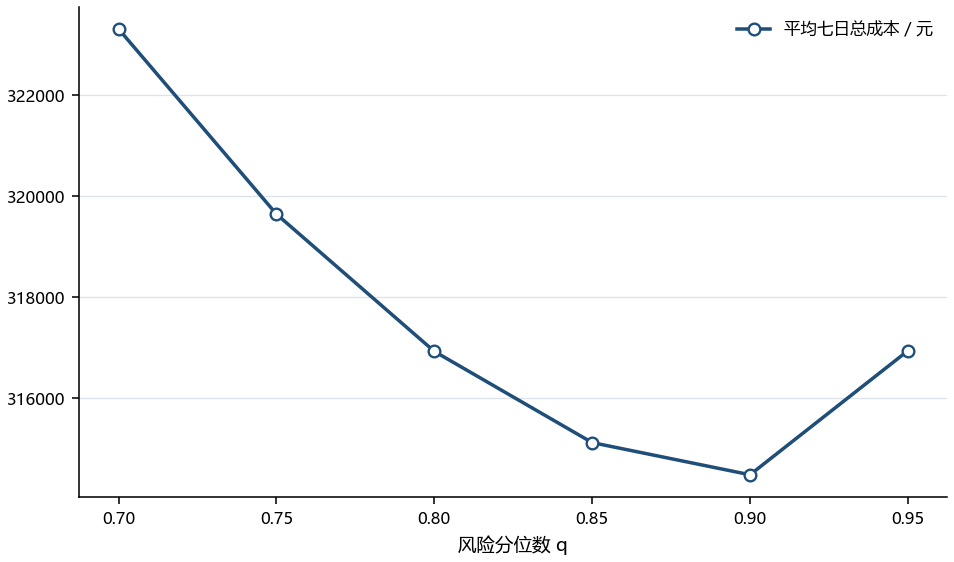

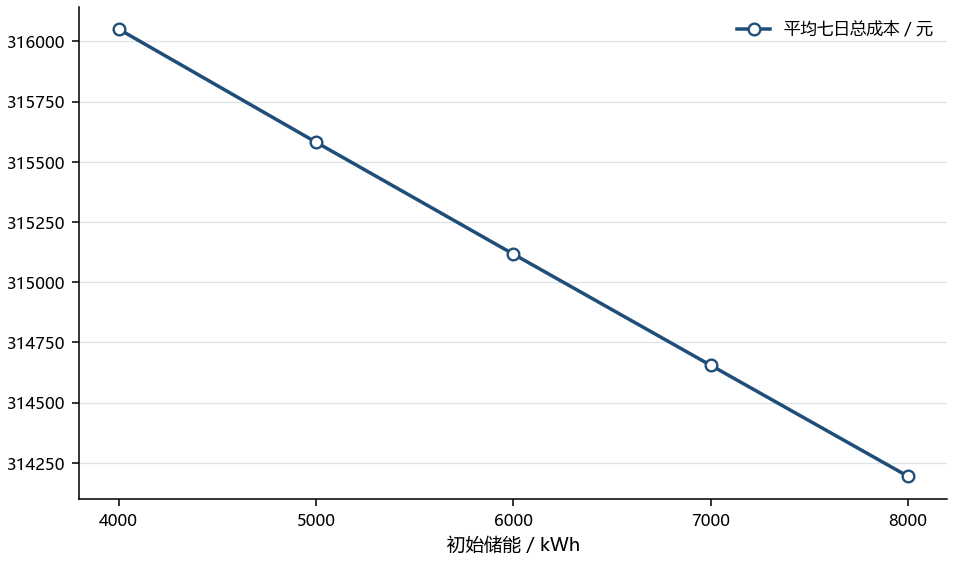

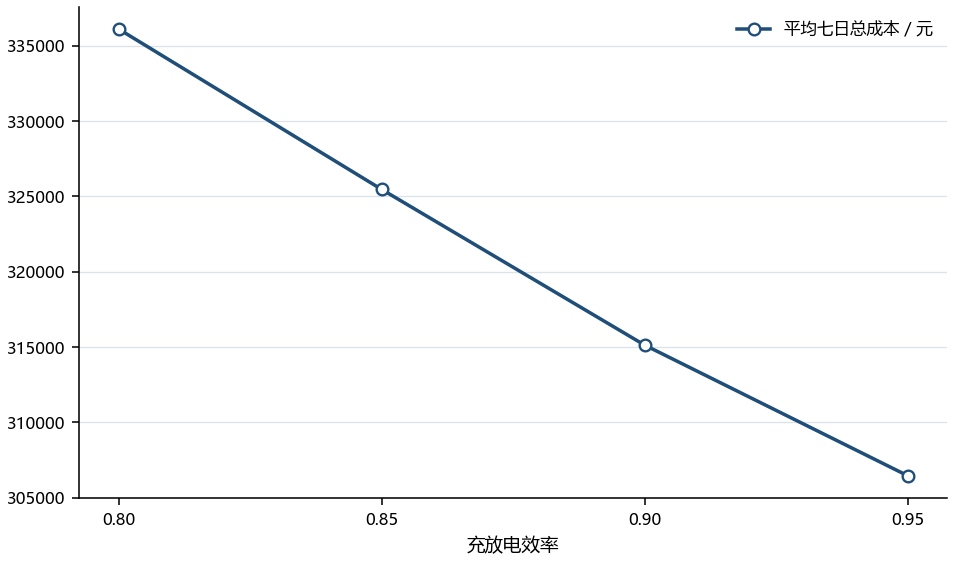

In [92]:
def publication_sensitivity_plot(frame, xcol, ycols, labels, colors, xlabel, stem):
    fig, ax = plt.subplots(figsize=(6.8, 4.0), constrained_layout=True)
    for ycol, label, color in zip(ycols, labels, colors):
        ax.plot(frame[xcol], frame[ycol], 'o-', color=color, markerfacecolor='white', markeredgewidth=1.2, label=label)
    ax.set_xlabel(xlabel)
    ax.set_xticks(frame[xcol])
    ax.grid(axis='y', color='#D9E1E8', linewidth=0.7, alpha=0.9)
    ax.grid(axis='x', visible=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc='best')
    save_publication_figure(fig, stem)
    plt.show()
    plt.close(fig)

publication_sensitivity_plot(
    q_summary, 'q', ['total_cost_yuan'], ['平均七日总成本 / 元'], ['#1F4E79'],
    '风险分位数 q', 'q4_fig04_q_sensitivity')
publication_sensitivity_plot(
    initial_summary, 'initial_storage_kwh', ['total_cost_yuan'], ['平均七日总成本 / 元'], ['#1F4E79'],
    '初始储能 / kWh', 'q4_fig05_initial_storage_sensitivity')
publication_sensitivity_plot(
    efficiency_summary, 'efficiency', ['total_cost_yuan'], ['平均七日总成本 / 元'], ['#1F4E79'],
    '充放电效率', 'q4_fig06_efficiency_sensitivity')

## 6. 窗口级增量成本分析

箱线图只能展示各目标下的成本分布，无法直接回答“提高终端储能目标多花了多少钱”。下面以 6000 kWh 为基准，绘制每个七日窗口的增量成本；热力图进一步展示季节窗口差异。

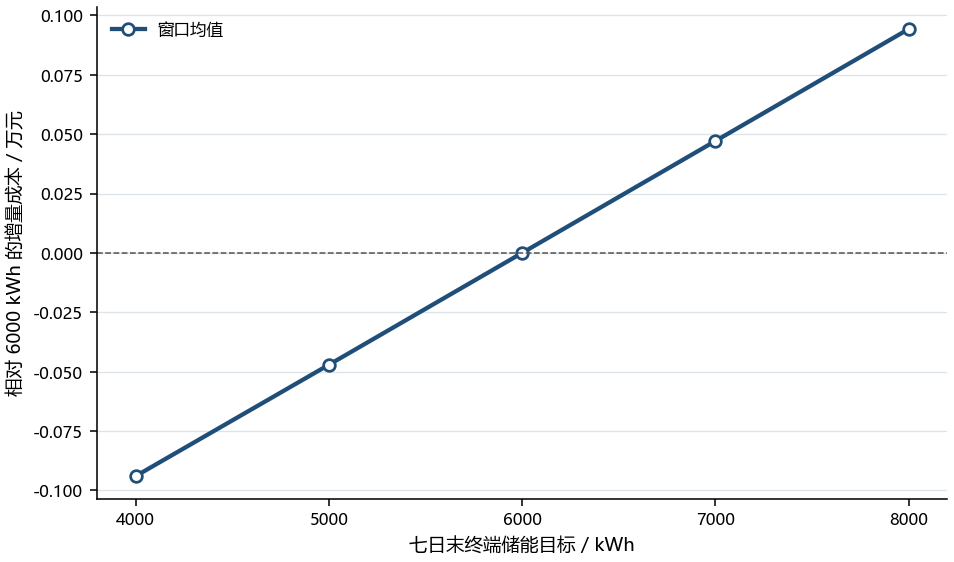

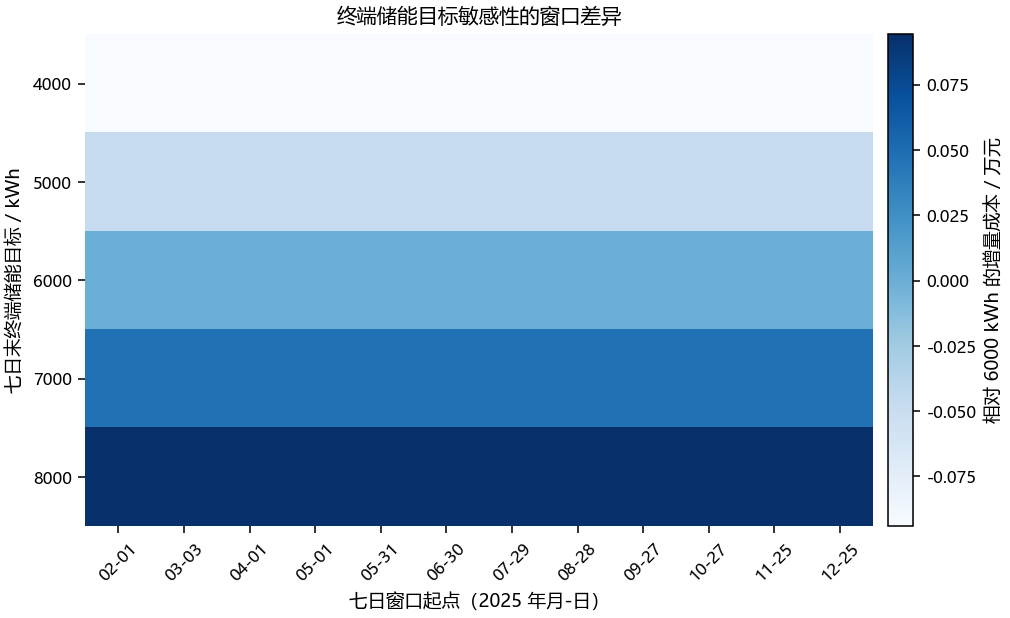

In [93]:
# 比箱线图更直接：每个窗口相对 6000 kWh 基准的增量成本。
window_cost = terminal_results.pivot_table(
    index='window_start',
    columns='terminal_target_kwh',
    values='total_cost_yuan',
    aggfunc='mean',
).sort_index()
base_target = 6000
if base_target not in window_cost.columns:
    raise KeyError(f'缺少基准终端目标 {base_target} kWh')
window_delta = (window_cost.subtract(window_cost[base_target], axis=0) / 1e4).sort_index(axis=1)
window_delta.to_csv(OUT / '09_terminal_target_incremental_cost_by_window.csv', encoding='utf-8-sig')

x_delta = window_delta.columns.to_numpy(dtype=float)
y_delta = window_delta.to_numpy(dtype=float)
if y_delta.ndim != 2 or y_delta.shape[1] != x_delta.size:
    raise ValueError(f'窗口增量成本维度错误: x={x_delta.shape}, y={y_delta.shape}')

fig, ax = plt.subplots(figsize=(6.8, 4.0), constrained_layout=True)
for row in y_delta:
    ax.plot(x_delta, row, color='#A9B7C6', linewidth=0.9, alpha=0.65, zorder=1)
mean_delta = np.nanmean(y_delta, axis=0)
ax.plot(x_delta, mean_delta, 'o-', color='#1F4E79', linewidth=2.2,
        markerfacecolor='white', markeredgewidth=1.4, label='窗口均值')
ax.axhline(0, color='#555555', linewidth=0.8, linestyle='--')
ax.set_xlabel('七日末终端储能目标 / kWh')
ax.set_ylabel('相对 6000 kWh 的增量成本 / 万元')
ax.set_xticks(x_delta)
ax.grid(axis='y', color='#D9E1E8', linewidth=0.7, alpha=0.9)
ax.grid(axis='x', visible=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, loc='best')
save_publication_figure(fig, 'q4_fig07_terminal_target_incremental_cost')
plt.show()
plt.close(fig)

# 低饱和蓝灰热力图：颜色用于表示增量成本大小，不强调红蓝对立。
fig, ax = plt.subplots(figsize=(7.2, 4.4), constrained_layout=True)
heat = ax.imshow(y_delta.T, aspect='auto', cmap='Blues', interpolation='nearest')
ax.set_yticks(np.arange(x_delta.size), [f'{v:.0f}' for v in x_delta])
ax.set_xticks(np.arange(window_delta.index.size), [str(v)[5:] for v in window_delta.index])
ax.set_xlabel('七日窗口起点（2025 年月-日）')
ax.set_ylabel('七日末终端储能目标 / kWh')
ax.tick_params(axis='x', rotation=45)
colorbar = fig.colorbar(heat, ax=ax, pad=0.02)
colorbar.set_label('相对 6000 kWh 的增量成本 / 万元')
ax.set_title('终端储能目标敏感性的窗口差异')
for spine in ax.spines.values():
    spine.set_visible(False)
save_publication_figure(fig, 'q4_fig08_terminal_target_incremental_cost_heatmap')
plt.show()
plt.close(fig)

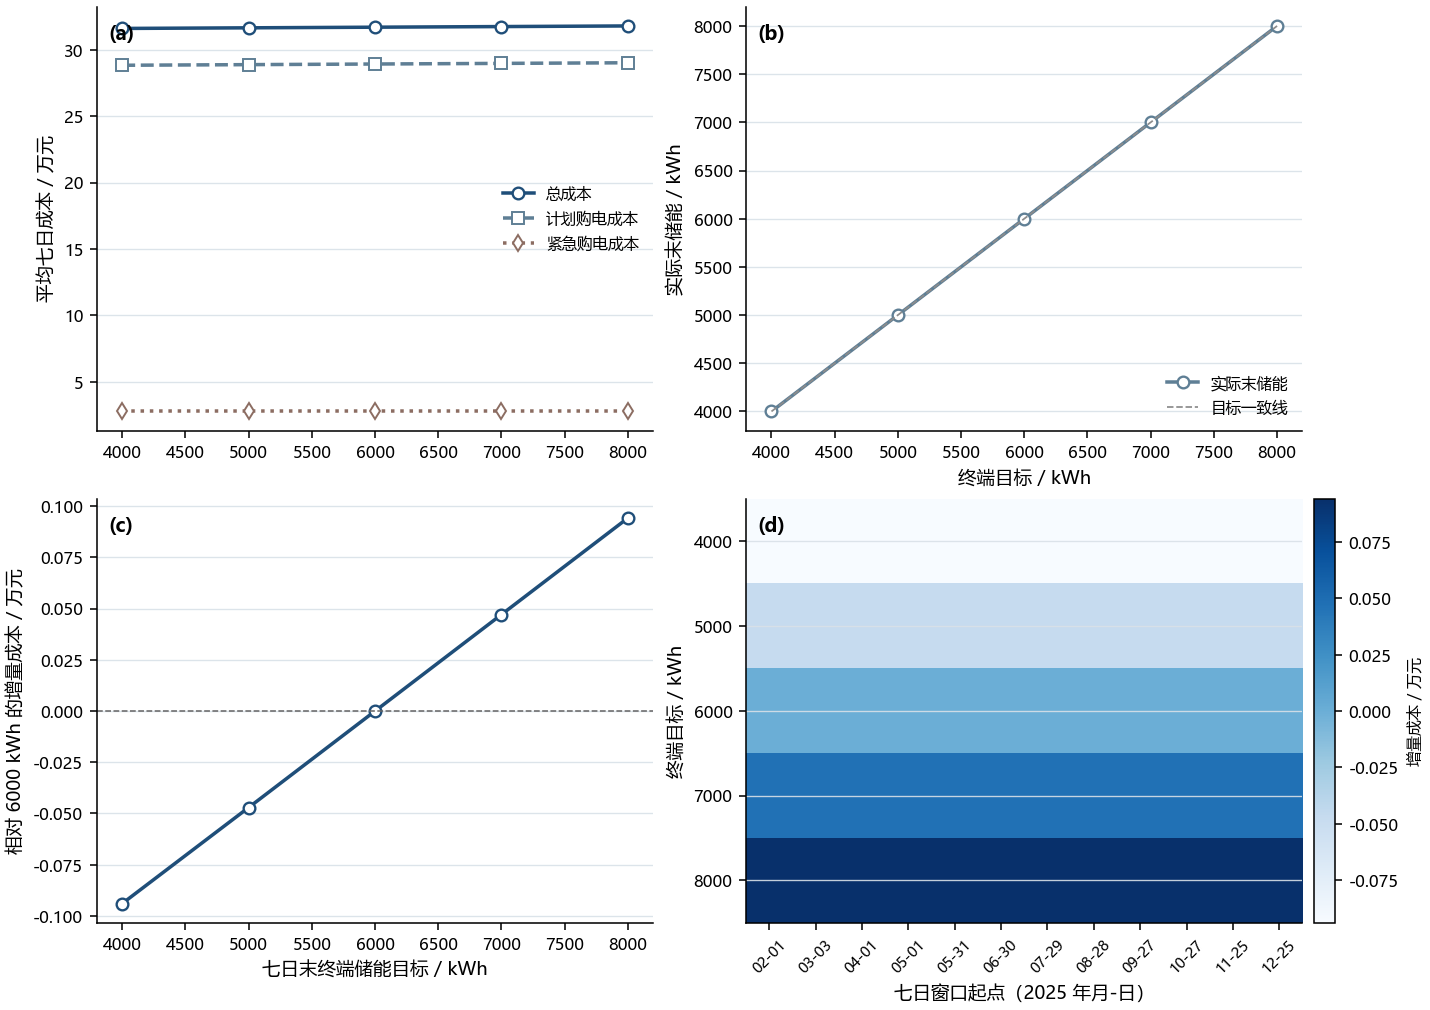

In [94]:
# 末尾组合图：把经济代价、约束满足和窗口差异放在同一张正文级图中。
fig, axes = plt.subplots(2, 2, figsize=(10.2, 7.2), constrained_layout=True)

# (a) 成本分解
planned_mean = terminal_results.groupby('terminal_target_kwh')['planned_cost_yuan'].mean().reindex(x).to_numpy() / 1e4
emergency_mean = terminal_results.groupby('terminal_target_kwh')['emergency_cost_yuan'].mean().reindex(x).to_numpy() / 1e4
total_mean = terminal_summary.set_index('terminal_target_kwh').reindex(x)['total_cost_yuan'].to_numpy() / 1e4
axes[0, 0].plot(x, total_mean, 'o-', color='#1F4E79', markerfacecolor='white', markeredgewidth=1.2, label='总成本')
axes[0, 0].plot(x, planned_mean, 's--', color='#5F7F95', markerfacecolor='white', markeredgewidth=1.0, label='计划购电成本')
axes[0, 0].plot(x, emergency_mean, 'd:', color='#8C6D62', markerfacecolor='white', markeredgewidth=1.0, label='紧急购电成本')
axes[0, 0].set_ylabel('平均七日成本 / 万元')
axes[0, 0].legend(frameon=False, fontsize=8, loc='best')

# (b) 终端目标执行效果：实际末储能与目标重合，虚线为理想一致线。
actual_terminal = terminal_summary.set_index('terminal_target_kwh').reindex(x)['terminal_storage_kwh'].to_numpy()
axes[0, 1].plot(x, actual_terminal, 'o-', color='#5F7F95', markerfacecolor='white', markeredgewidth=1.2, label='实际末储能')
axes[0, 1].plot(x, x, '--', color='#8C8C8C', linewidth=0.9, label='目标一致线')
axes[0, 1].set_xlabel('终端目标 / kWh')
axes[0, 1].set_ylabel('实际末储能 / kWh')
axes[0, 1].legend(frameon=False, fontsize=8, loc='best')

# (c) 平均增量成本
axes[1, 0].plot(x_delta, mean_delta, 'o-', color='#1F4E79', markerfacecolor='white', markeredgewidth=1.2)
axes[1, 0].axhline(0, color='#666666', linewidth=0.8, linestyle='--')
axes[1, 0].set_xlabel('七日末终端储能目标 / kWh')
axes[1, 0].set_ylabel('相对 6000 kWh 的增量成本 / 万元')

# (d) 低饱和热力图
heat = axes[1, 1].imshow(y_delta.T, aspect='auto', cmap='Blues', interpolation='nearest')
axes[1, 1].set_yticks(np.arange(x_delta.size), [f'{v:.0f}' for v in x_delta])
axes[1, 1].set_xticks(np.arange(window_delta.index.size), [str(v)[5:] for v in window_delta.index])
axes[1, 1].set_xlabel('七日窗口起点（2025 年月-日）')
axes[1, 1].set_ylabel('终端目标 / kWh')
axes[1, 1].tick_params(axis='x', rotation=45, labelsize=7.5)
colorbar = fig.colorbar(heat, ax=axes[1, 1], pad=0.02, fraction=0.046)
colorbar.set_label('增量成本 / 万元', fontsize=8)

for label, ax in zip(('(a)', '(b)', '(c)', '(d)'), axes.flat):
    ax.text(0.02, 0.96, label, transform=ax.transAxes, ha='left', va='top', fontsize=10, fontweight='bold')
    ax.grid(axis='y', color='#D9E1E8', linewidth=0.7, alpha=0.9)
    ax.grid(axis='x', visible=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
fig.savefig(OUT / 'q4_fig09_terminal_target_combined.png', dpi=300, bbox_inches='tight', pad_inches=0.05)
fig.savefig(OUT / 'q4_fig09_terminal_target_combined.pdf', bbox_inches='tight', pad_inches=0.05)
fig.savefig(PAPER_FIG_DIR / 'q4_fig09_terminal_target_combined.png', dpi=300, bbox_inches='tight', pad_inches=0.05)
fig.savefig(PAPER_FIG_DIR / 'q4_fig09_terminal_target_combined.pdf', bbox_inches='tight', pad_inches=0.05)
plt.show()
plt.close(fig)